In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [203]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


leggo il file csv:

In [204]:
df = pd.read_csv('/content/drive/MyDrive/Colab Numpy, Pandas, Pyplot/progetto disastri aerei/aviation-accidents.csv')
df.head()

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


converto le colonne nel formato piu corretto +
creo weekday per definire il nome del giorno

In [205]:
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce').fillna(0)
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%Y', errors='coerce')
df['weekday'] = df['date'].dt.day_name()

analizzo il file: visualizzo e rimuovo valori mancanti, valori duplicati e riassegno l'indice

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          23408 non-null  datetime64[ns]
 1   type          23967 non-null  object        
 2   registration  22419 non-null  object        
 3   operator      23963 non-null  object        
 4   fatalities    23967 non-null  float64       
 5   location      23019 non-null  object        
 6   country       23967 non-null  object        
 7   cat           23967 non-null  object        
 8   year          23906 non-null  Int64         
 9   weekday       23408 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), object(7)
memory usage: 1.9+ MB


In [207]:
df.shape

(23967, 10)

In [208]:
df.isna().sum()

,0
date,559
type,0
registration,1548
operator,4
fatalities,0
location,948
country,0
cat,0
year,61
weekday,559


In [209]:
df.duplicated().sum()

np.int64(117)

In [210]:
df[df.duplicated()].value_counts("country")

,count
country,
Netherlands,94
Greece,7
Russia,5
Germany,3
Norway,2
Hong Kong,2
Cuba,1
Canada,1
Israel,1


la maggior parte dei duplicati sono Netherlands, sotto il dettaglio. Assumo che non sia un problema ignorarli nell'analisi.

In [211]:
df[(df.duplicated())&(df['country'] == 'Netherlands')]

,date,type,registration,operator,fatalities,location,country,cat,year,weekday
568,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,Waalhaven,Netherlands,A1,1940,Friday
577,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,near Den Haag,Netherlands,A1,1940,Friday
579,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,Waalhaven,Netherlands,A1,1940,Friday
580,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,near Den Haag,Netherlands,A1,1940,Friday
581,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,near Den Haag,Netherlands,A1,1940,Friday
...,...,...,...,...,...,...,...,...,...,...
729,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,Waalhaven,Netherlands,A1,1940,Friday
730,1940-05-10,Junkers Ju-52/3m,NaN,German AF,0.0,Druten,Netherlands,A1,1940,Friday
741,1940-05-13,Junkers Ju-52/3m,NaN,German AF,0.0,Schipluiden,Netherlands,A1,1940,Monday
742,1940-05-13,Junkers Ju-52/3m,NaN,German AF,0.0,Schipluiden,Netherlands,A1,1940,Monday


In [212]:
df = df.drop_duplicates().dropna().reset_index(drop=True)

In [213]:
df

,date,type,registration,operator,fatalities,location,country,cat,year,weekday
0,1919-08-11,Felixstowe Fury,N123,RAF,1.0,near Felixtowe RNAS,U.K.,A1,1919,Monday
1,1920-02-23,Handley Page O/7,G-EANV,Handley Page Transport,0.0,"Acadia Siding, C...",South Africa,A1,1920,Monday
2,1920-02-25,Handley Page O/400,G-EAMC,Handley Page Transport,0.0,near El Shereik,Sudan,A1,1920,Wednesday
3,1920-06-30,Handley Page O/400,G-EAKE,Handley Page Transport,0.0,ÃstanÃ¥,Sweden,A1,1920,Wednesday
4,1920-12-14,Handley Page O/400,G-EAMA,Handley Page Transport,4.0,Golders Green,U.K.,A1,1920,Tuesday
...,...,...,...,...,...,...,...,...,...,...
21238,2023-05-11,Hawker 900XP,PK-LRU,Angkasa Super Services,0.0,Maleo Airport (MOH),Indonesia,A2,2023,Thursday
21239,2023-05-11,Cessna 208B Grand Caravan,PK-NGA,Nasional Global Aviasi,0.0,Fentheik Airstrip,Indonesia,A2,2023,Thursday
21240,2023-05-12,Cessna 208B Grand Caravan,5X-RBR,Bar Aviation,0.0,Kampala-Kajjansi...,Uganda,A1,2023,Friday
21241,2023-05-14,Boeing 747-4R7F,LX-OCV,Cargolux,0.0,Luxembourg-Finde...,Luxembourg,A2,2023,Sunday


## question 1: in quale nazione si sono verificati piu incidenti

conto quanti valori ci sono per nazione e imposto le prime 10 righe che vado poi a visualizzare nel pie chart

In [214]:
incidents_country = df['country'].value_counts().head(10)
print(incidents_country)

country
USA         4183
Russia      1225
U.K.         828
Canada       808
India        617
Brazil       595
France       523
Germany      449
China        442
Colombia     429
Name: count, dtype: int64


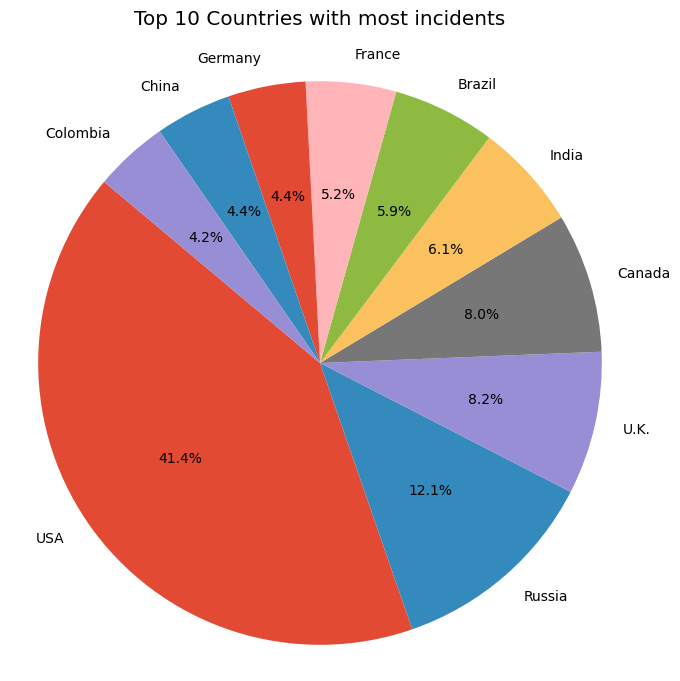

In [215]:
plt.figure(figsize=(8, 8))
plt.pie(incidents_country, labels=incidents_country.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Countries with most incidents\n')
plt.axis('equal')
plt.show()


EXPLANATION: il paese con piu incidenti aerei sono gli USA che occupano piu del 40% nella top 10.

## question 2: quali giorni hanno piu incidenti

conto quanti incidenti avvengono per giorno della settimana, ordinando i giorni monday - sunday

In [216]:
incidents_days = df['weekday'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print(incidents_days)

weekday
Monday       3012
Tuesday      3146
Wednesday    3197
Thursday     3211
Friday       3217
Saturday     2895
Sunday       2565
Name: count, dtype: int64


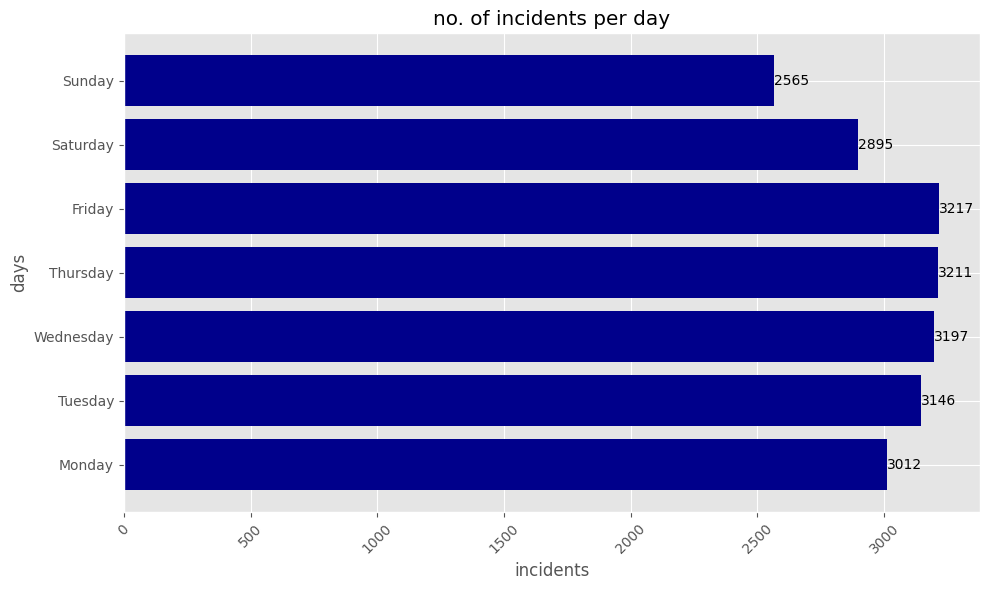

In [217]:
plt.figure(figsize=(10,6))
plt.style.use('ggplot')
bars1 = plt.barh(incidents_days.index, incidents_days.values, color='darkblue')
plt.bar_label(bars1)
plt.title('no. of incidents per day')
plt.xlabel('incidents')
plt.ylabel('days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

EXPLANATION: gli incidenti avvengono con minore frequenza nel weekend e inizio settimana, mentre aumentano nei giorni centrali.

##question 3: operatori piu sicuri nei paesi con piu incidenti


ho utilizzato incidents_country per avere le nazioni con piu incidenti. poi ho raggruppato gli operatori di quel paese per fatalities dove fatalities == 0, tenendo solo i primi 10 operatori.

In [218]:
print('safest operators in top 10 countries')
best = {}
for country in incidents_country.index:
  mask = df['country'] == country
  tmp = df[mask].groupby(['operator'])['fatalities'].sum()
  best[country] = tmp[tmp == 0].index.tolist()[:10]

best

safest operators in top 10 countries


{'USA': ['1982-047 LLC',
  '2M Leasing',
  '40-Mile Air',
  '987 Investments',
  'A.R. Wings',
  'ABA Aviation Resources',
  'ABS Equipment Leasing',
  'ABX Air',
  'AECA',
  'AMF Corp.'],
 'Russia': ['2nd Arkhangelsk United Aviation Division',
  '2nd Sverdlovsk Aviation Enterprise',
  'ALROSA',
  'Adygeya-Avia',
  'Aero-Transit',
  'AeroGeo',
  'AeroSvit Airlines',
  'AeroUral',
  'Aeroflot, Domodedovo',
  'Aeroflot, Kyrgyzstan'],
 'U.K.': ['ASL - Air Service Liege',
  'ASL Airlines Belgium',
  'AW Aerowest',
  'Aer Arann',
  'Aer Turas',
  'Aerocharter Midlands',
  'Aerospace Finance Leasing Inc',
  'Air Atlanta Icelandic',
  'Air Bridge Carriers',
  'Air Condor'],
 'Canada': ['ALCI Aviation, opf North Star Air Cargo',
  'Adlair',
  'Adventure Air',
  'Aerial Photography Co.',
  'Aero Cabo',
  'Aero Trades (Western)',
  'Aerokon Aviation',
  'Air Canada Express, opb Exploits Valley Air Services',
  'Air Canada Express, opb Jazz Aviation',
  'Air Canada Jazz'],
 'India': ['Aeroflot',


##question 4: quale tipo di velivolo ha causato piu morti

ho sommato le fatalities raggruppate per tipo di aircraft evidenziando le prime 10, costruendo il grafico sulla base di queste

In [219]:
deadliest_aircraft = df.groupby('type')['fatalities'].sum().sort_values(ascending=False).head(10)
print(deadliest_aircraft)

type
Douglas C-47A (DC-3)        5600.0
Douglas C-47 (DC-3)         2097.0
Douglas C-47B (DC-3)        1977.0
Tupolev Tu-154M             1395.0
Ilyushin Il-18V             1356.0
DC-9-32                     1207.0
Lockheed C-130H Hercules    1101.0
Douglas DC-6B               1040.0
DHC-6 Twin Otter 300        1036.0
Tupolev Tu-134A              868.0
Name: fatalities, dtype: float64


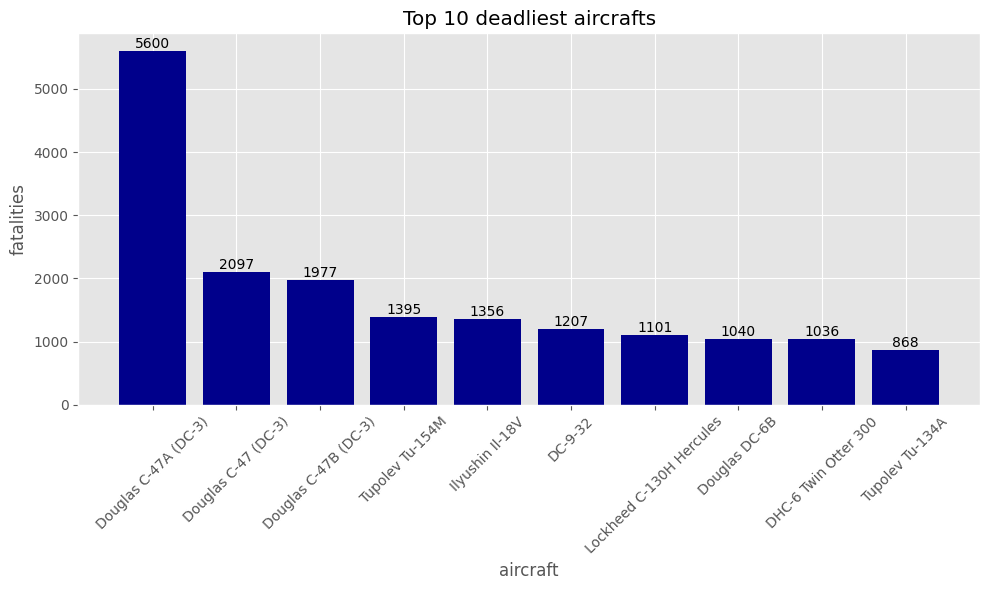

In [220]:
plt.figure(figsize=(10,6))
plt.style.use('ggplot')
bars2 = plt.bar(deadliest_aircraft.index, deadliest_aircraft.values, color='darkblue')
plt.bar_label(bars2)
plt.title('Top 10 deadliest aircrafts')
plt.xlabel('aircraft')
plt.ylabel('fatalities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

EXPLANATION: il grafico mostra i velivoli piu mortali

##question 5: come si sono evoluti gli incidenti dopo l'11 Settembre?

ho creato due variabili distinguendo prima e dopo 11 settembre,
contato i valori e costruito il grafico su questi dati

In [221]:
before_911 = df[df['date'] < '2001-09-11']
after_911 = df[df['date'] >= '2001-09-11']

incidents_before_911 = before_911['year'].value_counts().sort_index()
incidents_after_911 = after_911['year'].value_counts().sort_index()

print('incidents before 9-11\n', incidents_before_911.tail(10))
print('\n incidents after 9-11 \n', incidents_after_911.head(10))

incidents before 9-11
 year
1992    243
1993    249
1994    223
1995    254
1996    229
1997    211
1998    209
1999    228
2000    193
2001    129
Name: count, dtype: Int64

 incidents after 9-11 
 year
2001     75
2002    212
2003    209
2004    202
2005    215
2006    214
2007    214
2008    213
2009    200
2010    186
Name: count, dtype: Int64


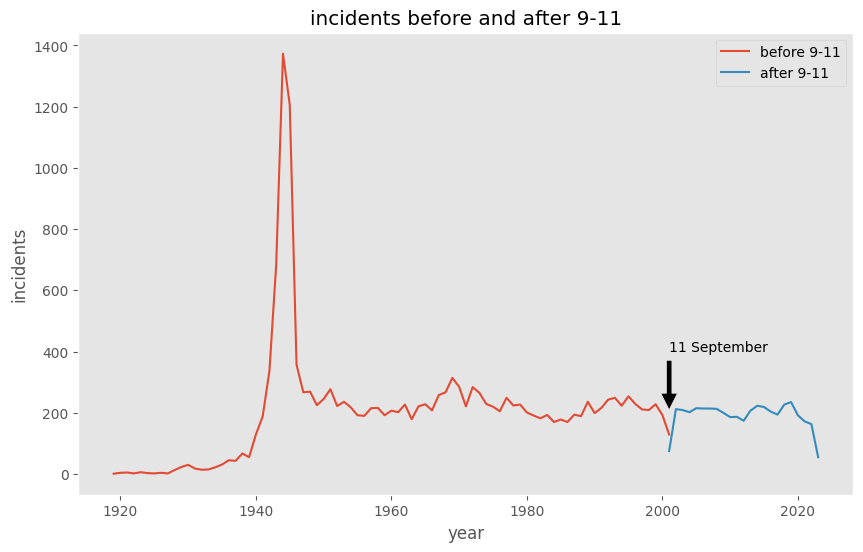

In [222]:
plt.figure(figsize=(10,6))
plt.plot(incidents_before_911, label='before 9-11')
plt.plot(incidents_after_911, label='after 9-11')
plt.legend()
plt.title('incidents before and after 9-11')
plt.annotate('11 September', xy=(2001,200),xytext=(2001,400),arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid()
plt.xlabel('year')
plt.ylabel('incidents')
plt.show()

## BONUS: importato geopandas con file che ho trovato in internet della cartina mondiale

<Axes: >

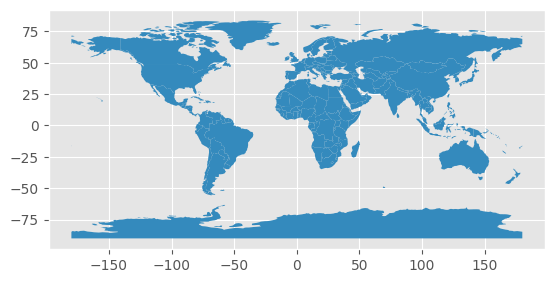

In [223]:
import geopandas as gpd

world = gpd.read_file('https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip')
world.plot()

per costruire il grafico ho seguito le istruzioni sul sito di geopandas

/tmp/ipython-input-3810833673.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


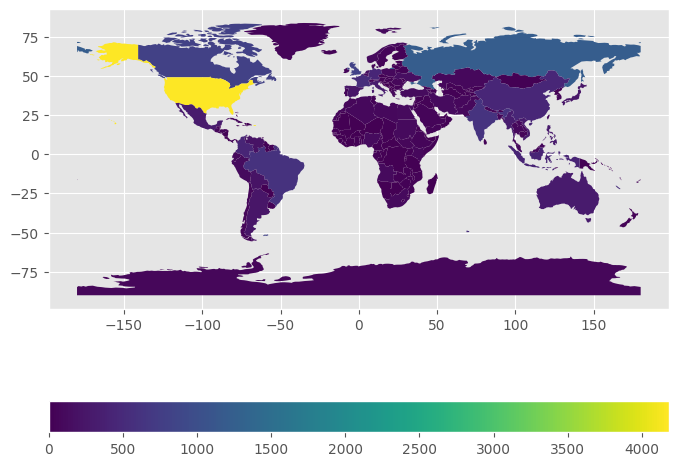

In [224]:
fig, ax = plt.subplots(figsize=(8, 8))

(
    world
    .rename(columns={'SOVEREIGNT': 'country'})
    .replace({'country': {'United States of America': 'USA', 'United Kingdom': 'U.K.'}})
    .set_index('country')
    .join(df['country'].value_counts().rename('count'))
    .fillna(0)
    .plot(column='count', ax=ax, legend=True,
    legend_kwds={'orientation':'horizontal'})
)

plt.show()
